In [ ]:
# Install dependencies
!pip install nltk scikit-learn pandas numpy

# Import libraries
import pandas as pd
import numpy as np
import nltk
import string
import pickle

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Download stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("IMDB Dataset.csv")
df.head()

Saving IMDB Dataset.csv to IMDB Dataset (1).csv


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
#Preprocess the test
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = ''.join(char for char in text if char not in string.punctuation)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

df['review'] = df['review'].apply(preprocess)
df.head()

,review,sentiment
0,one reviewers mentioned watching 1 oz episode ...,positive
1,wonderful little production br br filming tech...,positive
2,thought wonderful way spend time hot summer we...,positive
3,basically theres family little boy jake thinks...,negative
4,petter matteis love time money visually stunni...,positive


In [ ]:
#split the dataset
X = df['review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 40000
Testing Samples: 10000


In [ ]:
#Train the Naïve Bayes Model
model = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('nb', MultinomialNB())
])

model.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('nb', MultinomialNB())])

In [ ]:
#Evaluate the Model
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8701

Classification Report:

              precision    recall  f1-score   support

    negative       0.86      0.88      0.87      4961
    positive       0.88      0.86      0.87      5039

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000


Confusion Matrix:

[[4387  574]
 [ 725 4314]]


In [ ]:
#Test with Custom Input
sample_texts = [
    "I really enjoyed this movie",
    "This is the worst experience ever",
    "The product is average"
]

predictions = model.predict(sample_texts)

for text, sentiment in zip(sample_texts, predictions):
    print(f"Text: {text}")
    print(f"Predicted Sentiment: {sentiment}\n")

Text: I really enjoyed this movie
Predicted Sentiment: positive

Text: This is the worst experience ever
Predicted Sentiment: negative

Text: The product is average
Predicted Sentiment: positive



In [ ]:
#Save the Trained Model
with open("sentiment_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!


In [ ]:
from google.colab import files
files.download("sentiment_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

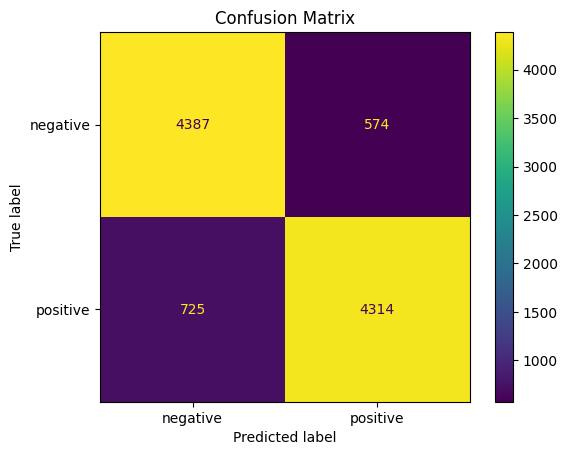

In [ ]:
#Visualize result
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.title("Confusion Matrix")
plt.show()